# Plot sylized trajectories (updated method)

In [1]:
import os,sys,glob,re
import pandas as pd
from datetime import datetime,timedelta
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
from matplotlib.axes import Axes
from matplotlib.colors import ListedColormap
from matplotlib import patches

%matplotlib inline


In [2]:
# load dem4cli

sys.path.append(os.path.join(os.environ['VSC_DATA_VO_USER'],'demographics4climate/'))
from population_demographics import * 
from lifetime_exposure import * 
from gmt_mapping import * 

In [3]:
figdir=os.path.join(os.getcwd(), '../_figures/fig_aug25')
os.makedirs(figdir, exist_ok=True)

In [4]:

# 1. Reset rcParams to defaults
mpl.rcdefaults()

# 2. Re-register the default Axes class
mpl.projections.register_projection(Axes)  # now 'plt.subplots()' uses normal Axes

In [5]:


# === Global style ===
plt.rcParams.update({
    "legend.frameon": False,       # no box around legend
})

# Custom color sequence
cmap_scenarios = ['gray', 'C0', 'orange', 'C3', 'maroon']
# Register it as a colormap
#mpl.colormaps.register(ListedColormap(cmap_scenarios, name="cmap_scenarios"))

# Custom Axes class to hide spines automatically
class CleanAxes(Axes):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        for spine in ["top", "right"]:
            self.spines[spine].set_visible(False)
# Register this class as the default for all plots
mpl.projections.register_projection(CleanAxes)

# add patch for readability of plots
def add_patch(ax):
    ax.add_patch(patches.Rectangle( 
        (0, 0), 1, 1,
        transform=ax.transAxes,
        color='white',
        zorder=-1
    ))


## Plot trajectories

In [6]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(1950, 2120)

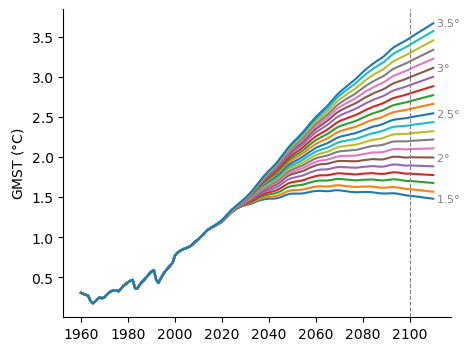

In [7]:
warminglevels = [1.5, 2, 2.5, 3, 3.5]
offsets = [-.01, 0, +.05, +.12, +.18]

fig, ax = plt.subplots(figsize=(5,4))

df_GMT_strj.loc[1960:2110].plot(ax=ax, legend=False)

ax.axvline(2100, ls='--', c='gray', lw=.8)
for lev, off in zip(warminglevels, offsets):
    ax.text(2111, lev+off, str(lev)+'$\degree$', c='gray', fontsize='8', va='center')

plt.ylabel('GMST ($\degree$C)')

#add_patch(ax)

plt.savefig(figdir+'/GMT_stylized_trajectories.png', 
    dpi=300, 
    bbox_inches='tight', 
    transparent=True)

In [8]:
df_GMT_strj

,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,...,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5
1960,0.306832,0.306832,0.306832,0.306832,0.306832,0.306832,0.306832,0.306832,0.306832,0.306832,...,0.306832,0.306832,0.306832,0.306832,0.306832,0.306832,0.306832,0.306832,0.306832,0.306832
1961,0.293686,0.293686,0.293686,0.293686,0.293686,0.293686,0.293686,0.293686,0.293686,0.293686,...,0.293686,0.293686,0.293686,0.293686,0.293686,0.293686,0.293686,0.293686,0.293686,0.293686
1962,0.281428,0.281428,0.281428,0.281428,0.281428,0.281428,0.281428,0.281428,0.281428,0.281428,...,0.281428,0.281428,0.281428,0.281428,0.281428,0.281428,0.281428,0.281428,0.281428,0.281428
1963,0.273481,0.273481,0.273481,0.273481,0.273481,0.273481,0.273481,0.273481,0.273481,0.273481,...,0.273481,0.273481,0.273481,0.273481,0.273481,0.273481,0.273481,0.273481,0.273481,0.273481
1964,0.206345,0.206345,0.206345,0.206345,0.206345,0.206345,0.206345,0.206345,0.206345,0.206345,...,0.206345,0.206345,0.206345,0.206345,0.206345,0.206345,0.206345,0.206345,0.206345,0.206345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,1.457691,1.549038,1.663222,1.765988,1.880171,1.995377,2.114671,2.231797,2.34133,2.460329,...,2.704635,2.820972,2.939893,3.065278,3.184782,3.308217,3.425884,3.552779,3.677368,3.781191
2117,1.453778,1.545746,1.660705,1.764169,1.879129,1.995157,2.115458,2.233572,2.344031,2.464062,...,2.71102,2.82862,2.948833,3.075579,3.196387,3.321184,3.44015,3.568446,3.69441,3.79938
2118,1.449864,1.542453,1.658188,1.762351,1.878086,1.994937,2.116245,2.235348,2.346731,2.467795,...,2.717406,2.836268,2.957772,3.085879,3.207992,3.334152,3.454416,3.584113,3.711452,3.817568
2119,1.44595,1.53916,1.655671,1.760532,1.877044,1.994717,2.117032,2.237123,2.349431,2.471528,...,2.723791,2.843916,2.966711,3.096179,3.219596,3.347119,3.468682,3.59978,3.728495,3.835756


array([1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7,
       2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5])